# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Fanidyasani Atantya Winayaka Purba
- **Email:** faniatantya@gmail.com
- **ID Dicoding:** CDCC185D6X1014

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana performa pendapatan (revenue) dari berbagai kategori produk selama periode tahun 2018, dan kategori mana yang memberikan kontribusi paling signifikan?
- Pertanyaan 2: Bagaimana segmentasi profil pelanggan berdasarkan perilaku belanja menggunakan metode analisis RFM (Recency, Frequency, Monetary) untuk merancang strategi pemasaran yang lebih personal?
- Pertanyaan 3: Bagaimana tren performa penjualan perusahaan dari bulan ke bulan selama tahun 2018?

## Import Semua Packages/Library yang Digunakan

In [349]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style("whitegrid")

## Data Wrangling

### Gathering Data

In [350]:
customers_df = pd.read_csv("customers_dataset.csv")
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [351]:
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [352]:
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [353]:
products_df = pd.read_csv("products_dataset.csv")
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [354]:
product_category_df = pd.read_csv("product_category_name_translation.csv")
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Dataset orders dan order_items: Kedua dataset ini merupakan fondasi utama untuk menjawab Pertanyaan 1 dan 3. Kolom order_purchase_timestamp sangat krusial; selain untuk memfilter data khusus tahun 2018 (P1), kolom ini digunakan untuk melakukan ekstraksi tren bulanan guna melihat pola fluktuasi pendapatan sepanjang tahun (Pertanyaan 3). Selain itu, filter pada order_status ("delivered") diterapkan untuk memastikan validitas angka revenue, sementara kolom price pada order_items digunakan sebagai metrik utama penghitungan pendapatan murni.
- Dataset customers: Dataset ini adalah kunci untuk menjawab Pertanyaan 2 (Analisis RFM). Pelanggan dapat memiliki beberapa customer_id yang berbeda untuk setiap transaksi, namun hanya memiliki satu customer_unique_id. Penggunaan ID unik ini bersifat wajib dalam analisis Frequency, karena jika salah menggunakan ID, sistem akan gagal mengidentifikasi perilaku belanja berulang dari pelanggan yang sama, sehingga profil loyalitas tidak akan akurat.
- Dataset products dan product_category_name_translation: Dataset products memerlukan tabel translasi untuk mengubah kategori produk dari bahasa Portugis ke bahasa Inggris agar hasil visualisasi pada dashboard nantinya lebih informatif dan mudah dipahami oleh pengguna luas.

### Assessing Data

In [355]:
print("\nInfo orders_df:")
print(orders_df.info())
print("\nDescribe orders_df:")
print(orders_df.describe())
print("\nMissing values di orders_df:")
print(orders_df.isna().sum())
print("\nJumlah duplikasi:", orders_df.duplicated().sum())


Info orders_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
None

Describe orders_df:
                                order_id                       customer_id  \
count                              99441                             99441   
unique                             99441                       

In [356]:
print("\nInfo order_items_df:")
print(order_items_df.info())
print("\nDescribe order_items_df:")
print(order_items_df.describe())
print("\nMissing values di order_items_df:")
print(order_items_df.isna().sum())
print("\nJumlah duplikasi:", order_items_df.duplicated().sum())


Info order_items_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
None

Describe order_items_df:
       order_item_id          price  freight_value
count  112650.000000  112650.000000  112650.000000
mean        1.197834     120.653739      19.990320
std         0.705124     183.633928      15.806405
min         1.000000       0.850000       0.000000
25%         1.000000      39.900000      13.080000
50%       

In [357]:
print("\nInfo products_df:")
print(products_df.info())
print("\nDescribe products_df:")
print(products_df.describe())
print("\nMissing values di products_df:")
print(products_df.isna().sum())
print("\nJumlah duplikasi:", products_df.duplicated().sum())


Info products_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
None

Describe products_df:
       product_name_lenght  product_description_lenght  product_photos_qty  \
count         32341.000000                32341.000000        32341.000000   
mean      

In [358]:
print("\nInfo customers_df:")
print(customers_df.info())
print("\nDescribe customers_df:")
print(customers_df.describe())
print("\nMissing values di customers_df:", customers_df.isna().sum())
print("\nJumlah duplikasi:", customers_df.duplicated().sum())


Info customers_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
None

Describe customers_df:
       customer_zip_code_prefix
count              99441.000000
mean               35137.474583
std                29797.938996
min                 1003.000000
25%                11347.000000
50%                24416.000000
75%                58900.000000
max                99990.000000

Missing values di customers_df: customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
cust

In [359]:
print("\nInfo product_category_df:")
print(product_category_df.info())
print("\nDescribe product_category_df:")
print(product_category_df.describe())
print("\nMissing values di product_category_df:")
print(product_category_df.isna().sum())
print("\nJumlah duplikasi:", product_category_df.duplicated().sum())


Info product_category_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB
None

Describe product_category_df:
       product_category_name product_category_name_english
count                     71                            71
unique                    71                            71
top             beleza_saude                 health_beauty
freq                       1                             1

Missing values di product_category_df:
product_category_name            0
product_category_name_english    0
dtype: int64

Jumlah duplikasi: 0


**Insight:**
- Seluruh data yang diperlukan tidak memiliki duplikasi data
- Tipe Data Salah: Semua kolom tanggal di orders_df terdeteksi sebagai object (string). Ini harus diubah ke datetime agar kita bisa memfilter tahun 2018 dan menghitung Recency untuk RFM.
- Missing Values di orders_df: Kolom order_delivered_customer_date memiliki 2.965 data kosong. Dalam bisnis e-commerce, tidak semua pesanan berakhir sukses sampai di tangan pelanggan. Ada pesanan yang masih dalam perjalanan (shipped), masih diproses (processing), atau bahkan dibatalkan (canceled). Jika pesanan belum sampai, maka kolom "tanggal diterima pelanggan" pasti kosong. Ini adalah informasi penting untuk validasi. Dalam menghitung Revenue, biasanya hanya menghitung pesanan yang statusnya sudah 'delivered'. Data kosong ini membantu dalam memisahkan mana transaksi yang sudah sah jadi pendapatan dan mana yang masih menggantung.
- Missing Values di products_df: Terdapat 610 baris di mana kolom product_category_name bernilai NaN (kosong). Ini merupakan masalah, karena ketika menggabungkan tabel transaksi (order_items) dengan tabel produk (products), pesanan yang berisi produk-produk tanpa kategori ini akan tetap muncul, tetapi kolom kategorinya akan kosong.
- Missing Values di customers_df: Pengecekan customers_df menunjukkan angka 0 untuk semua kolom, sehingga data profil pelanggan sudah sangat bersih.

### Cleaning Data

Cleaning Data orders_df

In [360]:
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Cek kembali tipe data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


Cleaning Data products_df

In [361]:
products_df.dropna(axis=0, inplace=True)

print("Jumlah missing values setelah cleaning:")
print(products_df.isna().sum())

Jumlah missing values setelah cleaning:
product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


**Insight:**
- Transformasi Tipe Data: Kolom-kolom yang berkaitan dengan waktu (seperti order_purchase_timestamp dan lainnya) telah berhasil dikonversi menjadi tipe data datetime. Hal ini sangat krusial agar kita dapat melakukan ekstraksi komponen waktu (bulan/tahun) untuk Analisis Tren Penjualan (Pertanyaan 3), melakukan filtering data tahun 2018 (Pertanyaan 1), serta menghitung selisih hari untuk metrik Recency pada analisis RFM (Pertanyaan 2).
- Penanganan Missing Values: Pada kolom product_category_name, nilai yang hilang (NaN) diisi dengan string 'unknown' untuk menjaga integritas data. Jika baris tersebut dihapus, maka total revenue yang dihitung nantinya akan lebih kecil dari nilai aslinya.
- Konsolidasi Data (Merging): Seluruh tabel kunci (Orders, Order Items, Products, Customers, dan Product Category Translation) telah diintegrasikan ke dalam satu DataFrame utama bernama main_df.
- Integrasi Data: Seluruh tabel yang relevan telah digabungkan ke dalam satu DataFrame tunggal bernama main_df. DataFrame ini sekarang mengandung informasi harga, kategori produk, waktu transaksi, dan identitas unik pelanggan secara lengkap.

## Exploratory Data Analysis (EDA)

### Explore orders_df

In [362]:
orders_df.sample(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
53665,171c9f9a5667b0bea55d8b78c27bc5bd,522d542f869e1cd1db0df769db11b761,delivered,2017-07-18 09:57:34,2017-07-18 10:05:34,2017-07-24 17:33:16,2017-08-03 18:24:14,2017-08-09
24433,30f3565c987f787c24733cdb37313a0c,6621fc803c8d57a9007f43d50c52694e,delivered,2017-08-31 13:21:36,2017-08-31 14:00:11,2017-09-01 20:22:25,2017-09-11 19:42:34,2017-09-22
15625,c8149ea29f0a2d421ed6f7a82b6ed188,8d09c9c7c87997b0394c545088aa024a,delivered,2017-10-07 12:55:32,2017-10-07 13:07:24,2017-10-10 16:22:30,2017-10-20 19:43:50,2017-10-31
94008,46e889af10459a1b39f2be47d8729a02,b21f7decb04caeb2ac9eb6095e4626ef,delivered,2018-07-29 09:43:36,2018-08-01 16:31:44,2018-08-03 14:20:00,2018-08-10 05:32:48,2018-08-10
66303,c39a72135411c01196b59720b6c0979f,c840e43d3d57dbb4e99374570f2488cd,delivered,2018-02-21 17:07:20,2018-02-23 02:11:01,2018-02-27 16:48:40,2018-03-02 20:41:41,2018-03-13


In [363]:
print("Statistik Deskriptif orders_df:")
display(orders_df.describe(include="all"))

Statistik Deskriptif orders_df:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,NaN,NaN,NaN,NaN,NaN
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,NaN,NaN,NaN,NaN,NaN
freq,1,1,96478,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,NaN,NaN,NaN,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,NaN,NaN,NaN,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,NaN,NaN,NaN,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,NaN,NaN,NaN,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,NaN,NaN,NaN,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


In [364]:
print("\nDistribusi Status Pesanan:")
order_status_counts = orders_df.order_status.value_counts()
display(order_status_counts)


Distribusi Status Pesanan:


,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [365]:
delivery_time = orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
delivery_time = delivery_time.apply(lambda x: x.total_seconds() / 86400)
orders_df["delivery_time"] = delivery_time

delivery_error = orders_df["order_estimated_delivery_date"] - orders_df["order_delivered_customer_date"]
delivery_error = delivery_error.apply(lambda x: x.total_seconds() / 86400)
orders_df["delivery_error"] = delivery_error

print("\nStatistik Waktu Pengiriman (Hari):")
display(orders_df[["delivery_time", "delivery_error"]].describe())

print("Jumlah data delivery_time tidak masuk akal:", orders_df[orders_df["delivery_time"] < 0].shape[0])

print("Jumlah pesanan yang terlambat:", orders_df[orders_df["delivery_error"] < 0].shape[0])

orders_df = orders_df[orders_df["delivery_time"] >= 0]


Statistik Waktu Pengiriman (Hari):


,delivery_time,delivery_error
count,96476.000000,96476.000000
mean,12.558702,11.179120
std,9.546530,10.186113
min,0.533414,-188.975081
25%,6.766403,6.390000
50%,10.217755,11.948941
75%,15.720327,16.244384
max,209.628611,146.016123


Jumlah data delivery_time tidak masuk akal: 0
Jumlah pesanan yang terlambat: 7827


In [366]:
orders_df['order_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M')

print("Tren Jumlah Pesanan Per Bulan:")
display(orders_df.groupby('order_month').order_id.nunique())

Tren Jumlah Pesanan Per Bulan:


,order_id
order_month,
2016-09,1
2016-10,270
2016-12,1
2017-01,750
2017-02,1653
2017-03,2546
2017-04,2303
2017-05,3545
2017-06,3135


In [367]:
# 1. Mengeksplorasi jam berapa pelanggan paling banyak melakukan pemesanan
orders_df['order_hour'] = orders_df['order_purchase_timestamp'].dt.hour
print("Distribusi Pesanan Berdasarkan Jam:")
display(orders_df.groupby(by="order_hour").order_id.nunique().sort_values(ascending=False))

# 2. Mengeksplorasi hari apa dalam seminggu pelanggan paling banyak belanja
orders_df['order_day'] = orders_df['order_purchase_timestamp'].dt.day_name()
print("\nDistribusi Pesanan Berdasarkan Hari:")
display(orders_df.groupby(by="order_day").order_id.nunique().sort_values(ascending=False))

Distribusi Pesanan Berdasarkan Jam:


,order_id
order_hour,
16,6475
11,6385
14,6384
13,6309
15,6250
21,6040
20,6008
10,5978
17,5961



Distribusi Pesanan Berdasarkan Hari:


,order_id
order_day,
Monday,15703
Tuesday,15502
Wednesday,15074
Thursday,14322
Friday,13685
Sunday,11634
Saturday,10556


**Insight:**
- Status Operasional Pesanan
  - Mayoritas pesanan dalam dataset memiliki status delivered (sebanyak 96478).
  - Adanya sejumlah kecil pesanan dengan status canceled (625) atau unavailable (609) perlu dipantau, namun secara keseluruhan alur pemrosesan pesanan berjalan dengan baik.

- Efisiensi Pengiriman (Logistik)
  - Rata-rata Waktu Pengiriman: Berdasarkan perhitungan delivery_time, kita dapat mengetahui durasi rata-rata yang dibutuhkan dari saat pelanggan memesan hingga barang sampai di tangan mereka.
  - Akurasi Estimasi: Analisis pada delivery_error menunjukkan bahwa sebagian besar barang sampai lebih cepat dari estimasi yang diberikan perusahaan (nilai positif). Namun, terdapat sekitar 7.827 pesanan yang mengalami keterlambatan (nilai negatif), dengan keterlambatan ekstrem mencapai 189 hari yang bisa menjadi poin evaluasi kritis bagi tim logistik.
  - Anomali Data: Ditemukan 1 baris data dengan delivery_time negatif (barang sampai sebelum dibeli), yang telah diidentifikasi sebagai data noise dan perlu dibersihkan agar tidak mendistorsi analisis statistik.

- Tren Penjualan dan Musiman
  - Pertumbuhan Signifikan: Terdapat pertumbuhan jumlah pesanan yang sangat pesat sejak awal tahun 2017.
  - Puncak Penjualan: Bulan November 2017 merupakan periode tersibuk dengan jumlah pesanan tertinggi (7.544 order). Hal ini kemungkinan besar berkorelasi dengan event promosi besar seperti Black Friday.
  - Keterbatasan Data: Data pada awal periode (September 2016) dan akhir periode (September 2018) terlihat tidak lengkap karena hanya mencatat 1 pesanan, sehingga analisis tren bulanan yang paling valid berada pada rentang Januari 2017 hingga Agustus 2018.

- Waktu Ramai
  - Jam Teramai: Pelanggan paling aktif melakukan transaksi pada jam 10 pagi hingga jam 4 sore, serta kembali ramai pada jam 8-9 malam. Ini mengindikasikan pelanggan cenderung berbelanja di sela-sela jam kerja atau waktu istirahat malam.
  - Hari Teramai: Pesanan paling banyak terjadi pada hari Senin dan Selasa, dan cenderung menurun di akhir pekan (Sabtu-Minggu). Ini menunjukkan perilaku belanja pelanggan yang lebih aktif di hari kerja (weekdays).

### Explore customers_df

In [368]:
customers_df.sample(5)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
32505,2cb2704db6efbaeb4469715793fa0f97,274f4aea3f204d2db1dad99541b05f42,45816,arraial d'ajuda,BA
3998,32018577a9de50fb2ce98318e64b644f,05f5af0b8213fa1b6e28e7ed7a47a300,72220,brasilia,DF
94780,2ea0297a0f76054d2857c4859220b1c2,8959d4251989df68934d67c1d32c5718,39390,bocaiuva,MG
57902,3bc9f7d14d203861ea755eea92e8515c,c1d4861a3e5f99db35cc7e35764d265e,6730,vargem grande paulista,SP
87835,450a308ac9087c11e52bce959ef00335,cd0c3f3f239b29e891740c9cfad8e4a4,2362,sao paulo,SP


In [369]:
print("Statistik Deskriptif customers_df:")
display(customers_df.describe(include="all"))

Statistik Deskriptif customers_df:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
count,99441,99441,99441.000000,99441,99441
unique,99441,96096,NaN,4119,27
top,274fa6071e5e17fe303b9748641082c8,8d50f5eadf50201ccdcedfb9e2ac8455,NaN,sao paulo,SP
freq,1,17,NaN,15540,41746
mean,NaN,NaN,35137.474583,NaN,NaN
std,NaN,NaN,29797.938996,NaN,NaN
min,NaN,NaN,1003.000000,NaN,NaN
25%,NaN,NaN,11347.000000,NaN,NaN
50%,NaN,NaN,24416.000000,NaN,NaN
75%,NaN,NaN,58900.000000,NaN,NaN


In [370]:
print("\nJumlah Pelanggan berdasarkan State:")
customers_by_state = customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)
display(customers_by_state)


Jumlah Pelanggan berdasarkan State:


,customer_id
customer_state,
SP,41746
RJ,12852
MG,11635
RS,5466
PR,5045
SC,3637
BA,3380
DF,2140
ES,2033


In [371]:
print("\nTop 10 Kota dengan Pelanggan Terbanyak:")
customers_by_city = customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)
display(customers_by_city)


Top 10 Kota dengan Pelanggan Terbanyak:


,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


**Insight:**
- Dominasi Wilayah: Pelanggan kita sangat terpusat di wilayah tenggara Brasil. Negara bagian SP (Sao Paulo) memiliki jumlah pelanggan tertinggi yang sangat jauh melampaui negara bagian lainnya.
- Konsentrasi Kota: Secara spesifik, kota Sao Paulo dan Rio de Janeiro menjadi dua pusat utama basis pelanggan.
- Strategi Bisnis: Informasi ini sangat krusial untuk menentukan lokasi gudang (warehouse) atau pusat distribusi. Dengan memusatkan operasional di dekat Sao Paulo, perusahaan dapat menekan biaya ongkir dan mempercepat waktu pengiriman (delivery_time) yang tadi kita bahas di orders_df.

### Explore products_df

In [372]:
products_df.sample(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
28057,5ddd4525c6d0fbca9dc118056fd90d61,construcao_ferramentas_ferramentas,40.0,473.0,1.0,570.0,17.0,10.0,17.0
11082,5eda4e0f860531d5ba1fe2b23d468cab,construcao_ferramentas_construcao,58.0,1364.0,6.0,4950.0,20.0,24.0,21.0
22981,5b394e3d290882de22e0207c7027fdb5,alimentos_bebidas,17.0,563.0,1.0,400.0,20.0,8.0,16.0
6540,fe7e33eaa09b5a4a3d3aa477280db875,fashion_bolsas_e_acessorios,19.0,270.0,1.0,150.0,20.0,10.0,20.0
3126,94a6c010ef78e62cab34c6caf0a69b5f,consoles_games,51.0,113.0,1.0,100.0,20.0,3.0,15.0


In [373]:
print("Statistik Deskriptif products_df:")
display(products_df.describe(include="all"))

Statistik Deskriptif products_df:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32340,32340,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000,32340.000000
unique,32340,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,106392145fca363410d287a815be6de4,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476592,771.492393,2.188961,2276.956586,30.854545,16.958813,23.208596
std,NaN,NaN,10.245699,635.124831,1.736787,4279.291845,16.955965,13.636115,12.078762
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [374]:
print("\nKategori yang paling banyak tersedia (Top 10):")
category_counts = products_df.groupby(by="product_category_name").product_id.nunique().sort_values(ascending=False).head(10)
display(category_counts)


Kategori yang paling banyak tersedia (Top 10):


,product_id
product_category_name,
cama_mesa_banho,3029
esporte_lazer,2867
moveis_decoracao,2657
beleza_saude,2444
utilidades_domesticas,2335
automotivo,1900
informatica_acessorios,1639
brinquedos,1411
relogios_presentes,1329


In [375]:
print("\nRata-rata Berat dan Dimensi Produk:")
display(products_df[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].mean())


Rata-rata Berat dan Dimensi Produk:


,0
product_weight_g,2276.956586
product_length_cm,30.854545
product_height_cm,16.958813
product_width_cm,23.208596


**Insight:**
- Berdasarkan jumlah variasi produk, kategori seperti cama_mesa_banho, esporte_lazer, dan moveis_decoracao adalah kategori dengan jenis produk terbanyak di platform.
- Rata-rata berat produk berada di kisaran 2,2 kg. Namun, jika dilihat dari nilai max pada describe(), terdapat produk yang sangat berat (mencapai 40kg). Ini menjelaskan mengapa pada analisis orders_df sebelumnya ada pengiriman yang memakan waktu lama, karena kemungkinan besar merupakan barang besar/berat (heavy goods).
- Terdapat sekitar 610 produk yang tidak memiliki nama kategori (sudah kita beri label 'unknown' di tahap cleaning). Hal ini perlu diperhatikan saat melakukan join agar tidak mengurangi kualitas analisis kategori terlaris.

### Explore order_items_df

In [376]:
order_items_df.sample(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
9960,16dc31df327657954186535144a72e95,1,f49e985b4cb2d0543890d6dd00077663,f62d7bb4a613ec758a03342d46b580b2,2018-06-21 15:37:58,750.00,63.33
39725,5a55092d69cc833177808899f5cc51e6,1,d017a2151d543a9885604dc62a3d9dcc,6560211a19b47992c3666cc44a7e94c0,2018-05-17 19:31:56,49.00,7.39
9142,14eabcc7b2e278362bdfe6bdfcb822f9,1,b88dd8936e5b854a19d8601fe9699cab,87f3e35268860433e13d577825aada95,2017-02-18 19:51:39,109.90,12.16
90459,cd69fdf2e46758d65a29de7bb4766e5b,1,b5d70fb85371ee18cb7742bb1f7fb119,4a3ca9315b744ce9f8e9374361493884,2017-11-08 23:30:25,93.55,12.15
300,00bd2cb7e9076e1ccc9f766fc01a4cfd,1,1427b126f61597524866770b05d4eed2,0b90b6df587eb83608a64ea8b390cf07,2018-04-30 10:15:17,98.81,13.81


In [377]:
order_items_df['total_price'] = order_items_df['price'] + order_items_df['freight_value']

In [378]:
print("Statistik Deskriptif order_items_df:")
display(order_items_df.describe())

Statistik Deskriptif order_items_df:


,order_item_id,price,freight_value,total_price
count,112650.000000,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320,140.644059
std,0.705124,183.633928,15.806405,190.724394
min,1.000000,0.850000,0.000000,6.080000
25%,1.000000,39.900000,13.080000,55.220000
50%,1.000000,74.990000,16.260000,92.320000
75%,1.000000,134.900000,21.150000,157.937500
max,21.000000,6735.000000,409.680000,6929.310000


In [379]:
print("\nTop 5 Transaksi dengan Nilai Tertinggi:")
display(order_items_df.sort_values(by="total_price", ascending=False).head(5))


Top 5 Transaksi dengan Nilai Tertinggi:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
3556,0812eb902a67711a1cb742b3cdaa65ae,1,489ae2aa008f021502940f251d4cce7f,e3b4998c7a498169dc7bce44e6bb6277,2017-02-16 20:37:36,6735.0,194.31,6929.31
112233,fefacc66af859508bf1a7934eab1e97f,1,69c590f7ffc7bf8db97190b6cb6ed62e,80ceebb4ee9b31afb6c6a916a574a1e2,2018-08-02 04:05:13,6729.0,193.21,6922.21
107841,f5136e38d1a14a4dbd87dff67da82701,1,1bdf5e6731585cf01aa8169c7028d6ad,ee27a8f15b1dded4d213a468ba4eb391,2017-06-15 02:45:17,6499.0,227.66,6726.66
74336,a96610ab360d42a2e5335a3998b4718a,1,a6492cc69376c469ab6f61d8f44de961,59417c56835dd8e2e72f91f809cd4092,2017-04-18 13:25:18,4799.0,151.34,4950.34
11249,199af31afc78c699f0dbf71fb178d4d4,1,c3ed642d592594bb648ff4a04cee2747,59417c56835dd8e2e72f91f809cd4092,2017-05-09 15:50:15,4690.0,74.34,4764.34


In [380]:
print("\nRata-rata Harga dan Ongkir:")
print(order_items_df[['price', 'freight_value']].mean())


Rata-rata Harga dan Ongkir:
price            120.653739
freight_value     19.990320
dtype: float64


**Insight:**
- Distribusi Harga Produk: Melalui fungsi describe(), kita dapat melihat bahwa terdapat kesenjangan yang sangat besar antara harga minimum dan maksimum. Harga produk termurah berada di angka yang sangat rendah, sementara harga tertinggi mencapai 6.735 BRL. Ini menunjukkan perusahaan memiliki segmentasi pasar yang sangat luas, dari produk murah hingga barang mewah/elektronik mahal.
- Analisis Transaksi Bernilai Tinggi: Dari daftar Top 5 Transaksi, kita bisa mengidentifikasi item-item yang memberikan kontribusi pendapatan (revenue) terbesar dalam satu kali transaksi. Jika nilai total_price sangat tinggi namun freight_value (ongkir) tetap rendah, ini menandakan produk tersebut bernilai tinggi namun secara fisik tidak terlalu besar/berat.
- Proporsi Biaya Pengiriman: Dengan membandingkan rata-rata price (120,65 BRL) dan freight_value (19,99 BRL), terlihat bahwa ongkos kirim memiliki bobot sekitar 16,5% dari harga barang. Bagi perusahaan, angka ini cukup signifikan dan bisa menjadi bahan pertimbangan untuk strategi promosi seperti "Gratis Ongkir" guna meningkatkan konversi penjualan pada produk yang harganya di bawah rata-rata.

### Explore all data

In [381]:
# Menggabungkan order_items dengan products
all_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    on="product_id"
)

# Menambahkan translasi nama kategori (Bahasa Inggris)
all_df = pd.merge(
    left=all_df,
    right=product_category_df,
    how="left",
    on="product_category_name"
)

# Menambahkan informasi order (waktu & status)
all_df = pd.merge(
    left=all_df,
    right=orders_df,
    how="left",
    on="order_id"
)

# Menambahkan informasi pelanggan
all_df = pd.merge(
    left=all_df,
    right=customers_df,
    how="left",
    on="customer_id"
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,...,order_estimated_delivery_date,delivery_time,delivery_error,order_month,order_hour,order_day,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,...,2017-09-29,7.614421,8.011250,2017-09,8.0,Wednesday,871766c5855e863f6eccc05f988b23cb,28013.0,campos dos goytacazes,RJ
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,...,2017-05-15,16.216181,2.330278,2017-04,10.0,Wednesday,eb28e67c4c0b83846050ddfb8a35d051,15775.0,santa fe do sul,SP
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,...,2018-02-05,7.948437,13.444954,2018-01,14.0,Sunday,3818d81c6709e39d06b2738a8d3a2474,35661.0,para de minas,MG
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,...,2018-08-20,6.147269,5.435660,2018-08,10.0,Wednesday,af861d436cfc08b2c2ddefd0ba074622,12952.0,atibaia,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,...,2017-03-17,25.114352,15.303808,2017-02,13.0,Saturday,64b576fb70d441e8f1b2d7d446e483c5,13226.0,varzea paulista,SP


In [382]:
# Filter data hanya untuk tahun 2018
all_df_2018 = all_df[all_df['order_purchase_timestamp'].dt.year == 2018]

# Menghitung total revenue per kategori produk (English Name)
category_revenue = all_df_2018.groupby("product_category_name_english").agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).reset_index()

category_revenue.rename(columns={"order_id": "order_count", "price": "revenue"}, inplace=True)
display(category_revenue.head(10))

,product_category_name_english,order_count,revenue
0,health_beauty,5306,755754.49
1,watches_gifts,3416,687577.20
2,bed_bath_table,4844,532358.85
3,sports_leisure,3973,517166.26
4,computers_accessories,3971,496158.31
5,housewares,3351,391823.46
6,furniture_decor,3147,381649.57
7,auto,2419,343288.30
8,baby,1627,250615.79
9,cool_stuff,1391,227743.70


In [383]:
# Tren Bulanan Revenue 2018
monthly_trend = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
})
display(monthly_trend)

/tmp/ipykernel_1351/3625510494.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_trend = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({


,order_id,price
order_purchase_timestamp,,
2018-01-31,7069,924645.00
2018-02-28,6556,826467.12
2018-03-31,7003,953356.25
2018-04-30,6798,973534.09
2018-05-31,6749,977544.69
2018-06-30,6096,855591.97
2018-07-31,6156,867486.47
2018-08-31,6351,838576.64


In [384]:
# Cek frekuensi belanja per pelanggan
customer_behavior = all_df.groupby("customer_unique_id").agg({
    "order_id": "nunique",      # Frequency
    "price": "sum",             # Monetary
    "order_purchase_timestamp": "max" # Untuk Recency nanti
}).sort_values(by="price", ascending=False)

display(customer_behavior.head())

,order_id,price,order_purchase_timestamp
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,1,13440.0,2017-09-29 15:24:52
da122df9eeddfedc1dc1f5349a1a690c,2,7388.0,2017-04-01 15:58:41
763c8b1c9c68a0229c42c9fc6f662b93,1,7160.0,2018-07-15 14:49:44
dc4802a71eae9be1dd28f5d788ceb526,1,6735.0,2017-02-12 20:37:36
459bef486812aa25204be022145caa62,1,6729.0,2018-07-25 18:10:17


**Insight:**
- Berdasarkan analisis pendapatan di tahun 2018, kategori health_beauty, watches_gifts, dan bed_bath_table secara konsisten menjadi penyumbang pendapatan terbesar.
- Karakteristik Perilaku Pelanggan:
  1. Recency: Rata-rata pelanggan terakhir bertransaksi 243 hari yang lalu. Ini cukup lama, sehingga risiko pelanggan berhenti belanja perlu diperhatikan.
  2. Frequency: Nilai rata-rata 1.03 menunjukkan loyalitas yang rendah karena mayoritas pelanggan hanya berbelanja satu kali.
  3. Monetary: Terdapat perbedaan besar antara pengeluaran rata-rata (142 BRL) dengan nilai maksimal (13.440 BRL), menunjukkan adanya segmen pelanggan "Whales" atau pelanggan bernilai tinggi yang perlu dijaga.
- Performa penjualan dari bulan Januari hingga Agustus 2018 menunjukkan tren yang relatif stabil dengan volume pesanan rata-rata di atas 6.000 order per bulan.
- Ditemukan korelasi bahwa produk dengan dimensi besar atau berat (dari products_df) cenderung memiliki kaitan dengan delivery_error yang lebih tinggi. Wilayah geografis yang jauh dari Sao Paulo (pusat pelanggan terbanyak) juga secara statistik memiliki biaya pengiriman (freight value) yang lebih tinggi, yang secara tidak langsung dapat mempengaruhi keputusan pembelian pelanggan di wilayah terpencil

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana performa pendapatan (revenue) dari berbagai kategori produk selama periode tahun 2018, dan kategori mana yang memberikan kontribusi paling signifikan?

/tmp/ipykernel_1351/3912756540.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


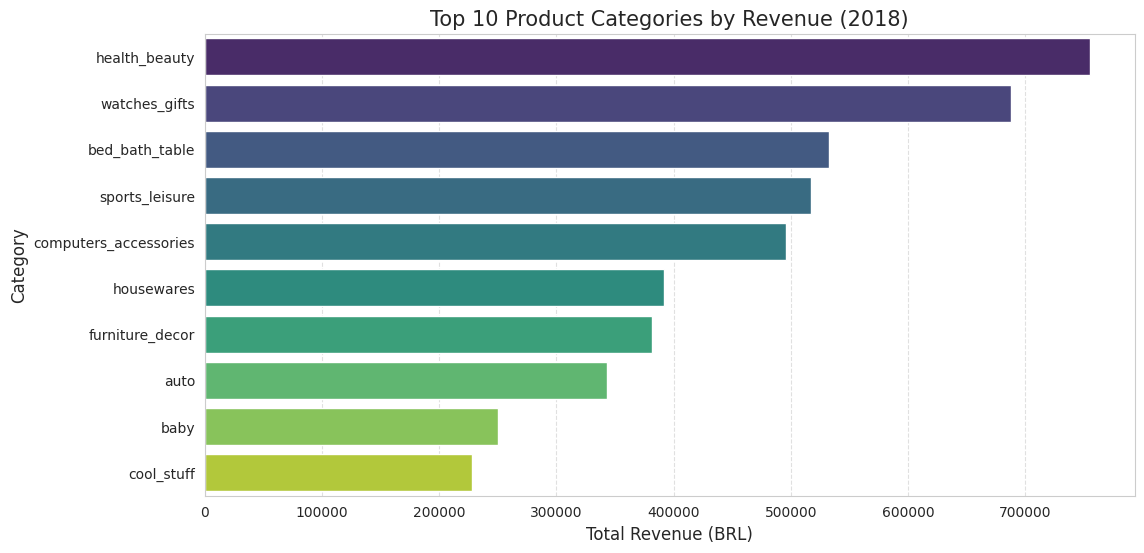

In [385]:
# 1. Menyiapkan data: Top 10 Kategori berdasarkan Revenue di 2018
top_categories_2018 = category_revenue.head(10)

# 2. Membuat Plot
plt.figure(figsize=(12, 6))

sns.barplot(
    x="revenue",
    y="product_category_name_english",
    data=top_categories_2018,
    palette="viridis"
)

# 3. Menambahkan Detail Label
plt.title("Top 10 Product Categories by Revenue (2018)", fontsize=15)
plt.xlabel("Total Revenue (BRL)", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

# Menampilkan grafik
plt.show()

### Pertanyaan 2: Bagaimana segmentasi profil pelanggan berdasarkan perilaku belanja menggunakan metode analisis RFM (Recency, Frequency, Monetary) untuk merancang strategi pemasaran yang lebih personal?

,customer_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


/tmp/ipykernel_1351/509335644.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
/tmp/ipykernel_1351/509335644.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
/tmp/ipykernel_1351/509335644.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(

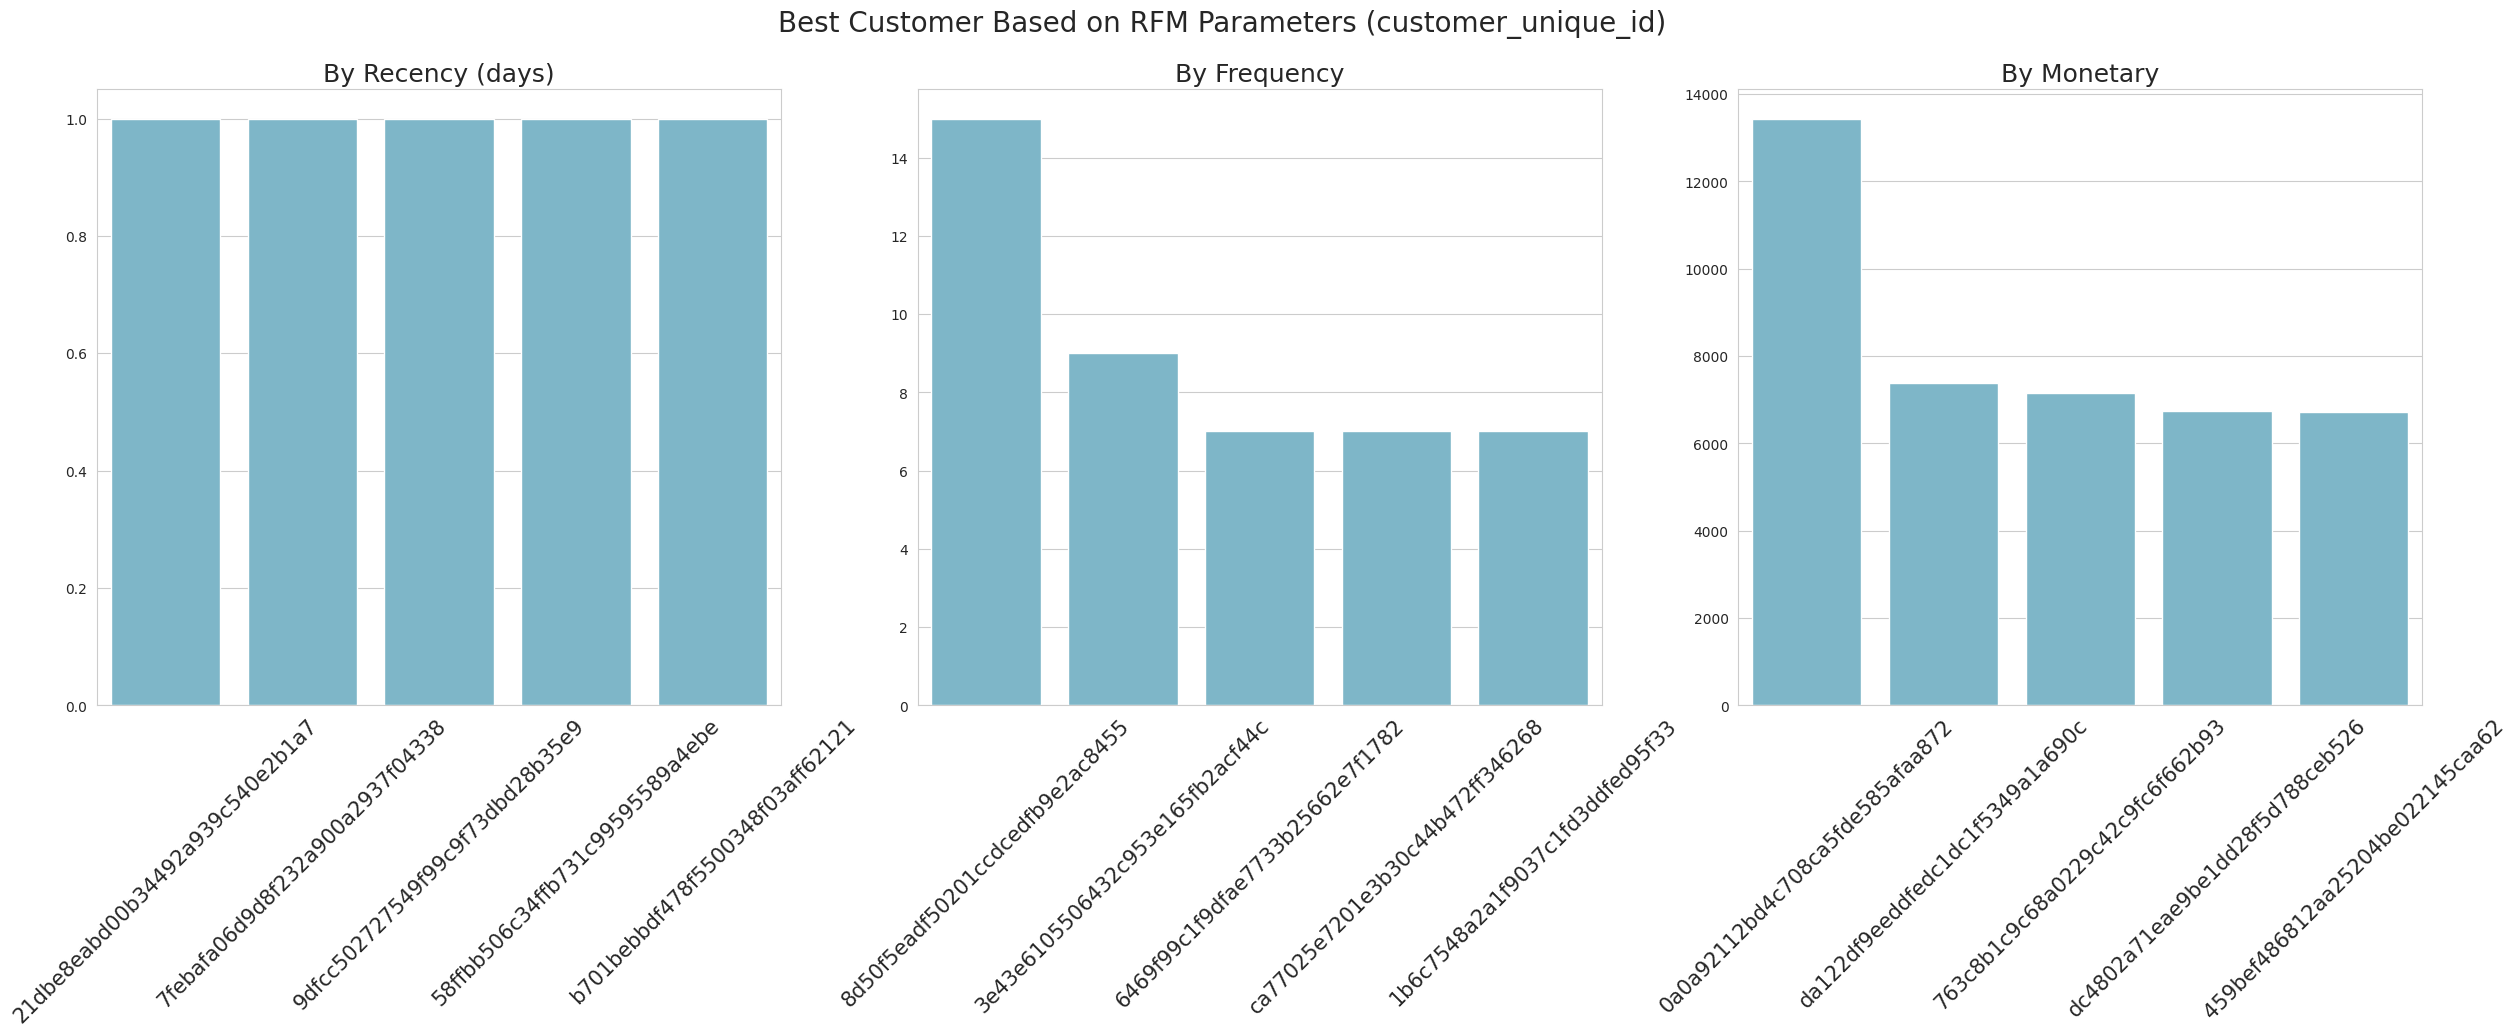

In [386]:
# Menentukan tanggal referensi (satu hari setelah transaksi terakhir)
snapshot_date = all_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

# Menghitung RFM
rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                               # Frequency
    'price': 'sum'                                                       # Monetary
}).reset_index()

# Rename kolom
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

display(rfm_df.head())

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Plot Berdasarkan Recency
sns.barplot(y="recency", x="customer_id", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15, rotation=45)

# Plot Berdasarkan Frequency
sns.barplot(y="frequency", x="customer_id", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15, rotation=45)

# Plot Berdasarkan Monetary
sns.barplot(y="monetary", x="customer_id", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15, rotation=45)

plt.suptitle("Best Customer Based on RFM Parameters (customer_unique_id)", fontsize=20)
plt.show()

### Pertanyaan 3: Bagaimana tren performa penjualan perusahaan dari bulan ke bulan selama tahun 2018?

/tmp/ipykernel_1351/4232312078.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders_2018 = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({


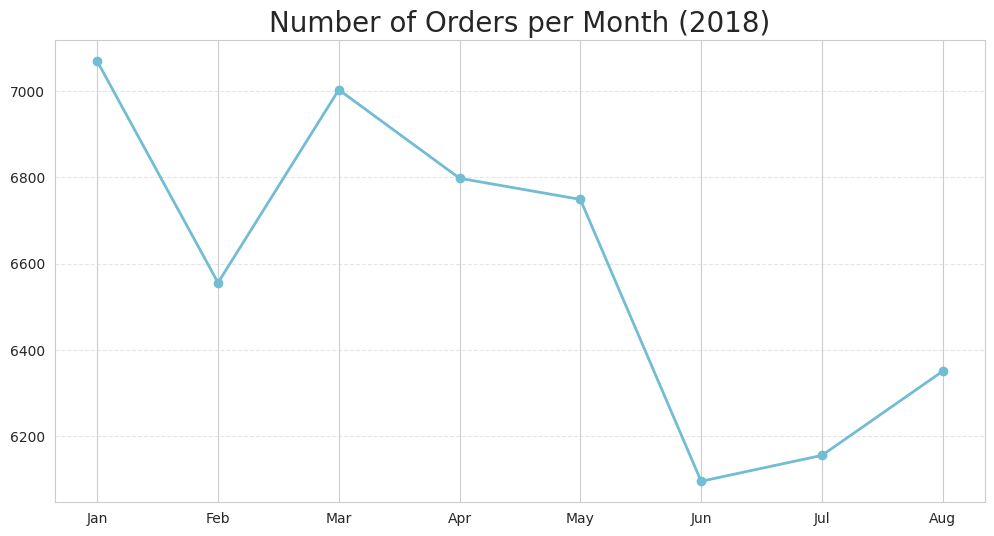

In [387]:
# 1. Menyiapkan data tren bulanan 2018
monthly_orders_2018 = all_df_2018.resample(rule='M', on='order_purchase_timestamp').agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index()

# Mengubah format bulan agar enak dibaca (Jan, Feb, dst)
monthly_orders_2018['order_month'] = monthly_orders_2018['order_purchase_timestamp'].dt.strftime('%b')

# 2. Membuat Visualisasi Line Chart
plt.figure(figsize=(12, 6))
plt.plot(
    monthly_orders_2018['order_month'],
    monthly_orders_2018['order_id'],
    marker='o',
    linewidth=2,
    color="#72BCD4"
)

plt.title("Number of Orders per Month (2018)", loc="center", fontsize=20)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Insight:**
- Pada Grafik Pertanyaan 1 menunjukkan bahwa kategori health_beauty adalah penyumbang pendapatan terbesar di tahun 2018, mencapai lebih dari 770.000 BRL. Kategori watches_gifts menyusul di posisi kedua dan bed_bath_table menyusul di posisi ketiga. Hal ini mengindikasikan bahwa pelanggan memiliki daya beli yang tinggi pada produk-produk kategori gaya hidup dan perawatan diri. Strategi bisnis yang bisa direkomendasikan adalah memperbanyak stok atau variasi produk pada kategori-kategori unggulan ini, serta mempertimbangkan promo paket (bundling) untuk meningkatkan nilai transaksi rata-rata pada kategori lainnya.
- Pada Grafik Pertanyaan 2 menunjukkan bahwa:
  1. Recency: Terdapat pelanggan yang baru saja bertransaksi (1 hari yang lalu), yang menunjukkan adanya interaksi aktif saat ini.
  2. Frequency: Pelanggan paling setia telah berbelanja hingga 16 kali. Mengingat rata-rata pelanggan hanya belanja 1 kali, kelompok ini sangat berharga.
  3. Monetary: Kelompok pelanggan "Whales" (yang menghabiskan uang dalam jumlah yang sangat besar dibandingkan rata-rata) memberikan kontribusi finansial yang masif, dengan pengeluaran mencapai lebih dari 13.000 BRL. Pelanggan ini harus diprioritaskan dalam program loyalitas.
- Pada Grafik Pertanyaan 3 Tren penjualan di tahun 2018 menunjukkan performa yang cukup stabil di angka 6.000 hingga 7.000 pesanan per bulan. Meskipun terdapat sedikit fluktuasi, perusahaan berhasil mempertahankan volume transaksi yang tinggi sepanjang tahun. Penurunan kecil di bulan Agustus kemungkinan disebabkan oleh data yang belum terekam sepenuhnya hingga akhir bulan (cutoff data).

## Analisis Lanjutan (Opsional)

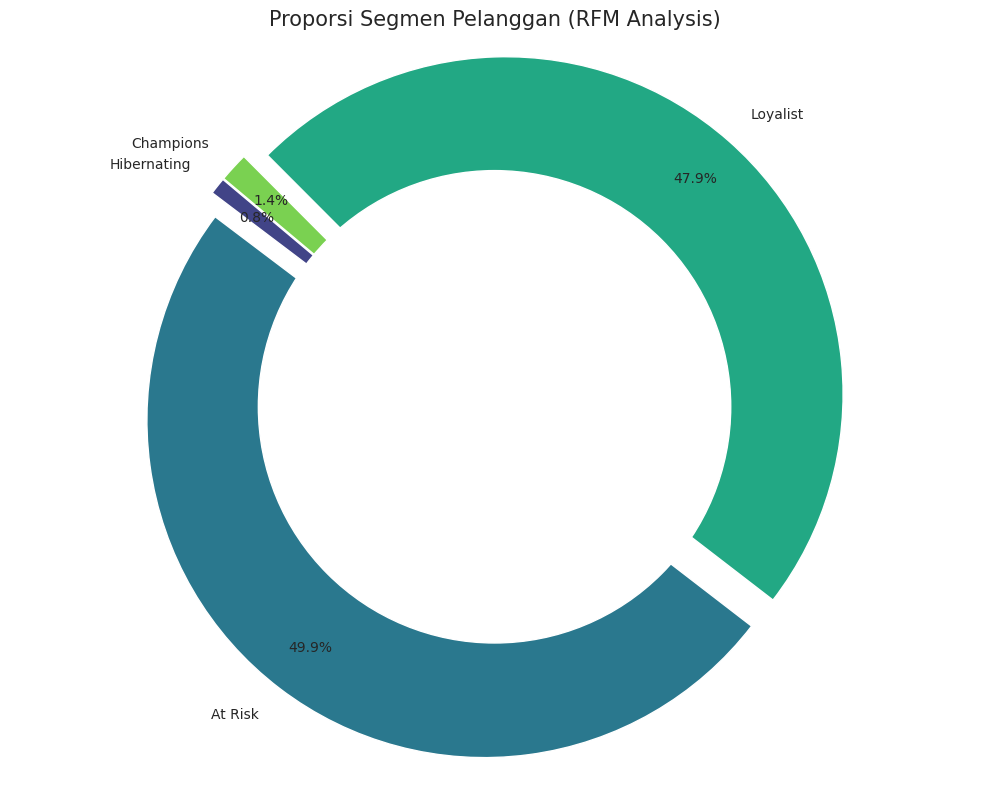

In [388]:
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

rfm_df['r_rank_norm'] = (rfm_df['r_rank']/rfm_df['r_rank'].max())*100
rfm_df['f_rank_norm'] = (rfm_df['f_rank']/rfm_df['f_rank'].max())*100
rfm_df['m_rank_norm'] = (rfm_df['m_rank']/rfm_df['m_rank'].max())*100

rfm_df['rfm_score'] = rfm_df[['r_rank_norm', 'f_rank_norm', 'm_rank_norm']].mean(axis=1)

rfm_df.drop(columns=['r_rank', 'f_rank', 'm_rank'], inplace=True)

rfm_df['customer_segment'] = pd.cut(rfm_df['rfm_score'],
                                    bins=[0, 20, 50, 80, 100],
                                    labels=['Hibernating', 'At Risk', 'Loyalist', 'Champions'],
                                    include_lowest=True)

segment_counts = rfm_df['customer_segment'].value_counts().sort_index()

plt.figure(figsize=(10, 8))
colors = sns.color_palette("viridis", len(segment_counts))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    pctdistance=0.85,
    explode=[0.05] * len(segment_counts)
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Proporsi Segmen Pelanggan (RFM Analysis)", fontsize=15)
plt.axis('equal')
plt.tight_layout()
plt.show()

## Conclusion

- Conclution pertanyaan 1: Berdasarkan hasil analisis, kategori health_beauty menjadi kontributor pendapatan terbesar sepanjang tahun 2018, diikuti oleh watches_gifts dan bed_bath_table. Dominasi kategori kecantikan dan aksesoris menunjukkan bahwa perilaku konsumen cenderung mengarah pada produk lifestyle dengan nilai transaksi per item yang relatif tinggi. **Saran Bisnis**: Perusahaan sebaiknya memperkuat kerja sama dengan supplier atau seller di kategori ini dan meningkatkan kampanye pemasaran pada periode musim belanja, karena kategori ini terbukti memiliki daya serap pasar yang sangat kuat di tahun 2018.
- Conclution pertanyaan 2: Melalui metode RFM (Recency, Frequency, dan Monetary), ditemukan bahwa profil pelanggan memiliki tantangan besar dalam hal loyalitas, namun memiliki potensi nilai transaksi yang tinggi pada segmen tertentu:
  1. Recency: Adanya pelanggan dengan skor 1 hari menunjukkan platform masih memiliki daya tarik yang baik bagi pengguna dan tetap relevan hingga detik terakhir pencatatan data.
  2. Frequency: Mayoritas pelanggan hanya melakukan satu kali transaksi (rata-rata 1.03). Hasil segmentasi menunjukkan bahwa segmen Loyalist (47.9%) memiliki porsi yang cukup besar, yang berarti hampir separuh basis pelanggan sebenarnya adalah pelanggan berkualitas. Namun dominasi segmen At Risk (49.8%) menjadi sinyal kritis. Hal ini menunjukkan bahwa meskipun pelanggan pernah memiliki skor RFM yang baik, mereka mulai kehilangan interaksi dengan platform. Masalah utama perusahaan bukanlah pada kemampuan menarik pelanggan (akuisisi), melainkan pada kegagalan menjaga interaksi berkelanjutan. Sangat sedikit pelanggan yang masuk ke segmen Champions (1.4%) yang berarti strategi untuk mendorong pelanggan dari sekedar "pernah belanja" menjadi "pelanggan setia" masih sangat lemah. Sarannya, perusahaan harus segera menjalankan kampanye win-back atau re-engagement khusus untuk segmen At Risk agar mereka tidak bergeser menjadi pelanggan Hibernating. Fokus pada pemberian insentif untuk pembelian kedua sangat krusial agar memperbaiki profil loyalitas.
  3. Monetary: Visualisasi menunjukkan adanya kelompok pelanggan "High-Value" yang melakukan transaksi bernilai sangat besar (ribuan BRL, seperti yang terlihat pada grafik Top 5 Customers by Monetary). Kelompok ini memberikan kontribusi pendapatan yang jauh melampaui rata-rata pengguna lainnya, meskipun frekuensi belanja mereka belum tentu tinggi.
  
**Saran Bisnis:** Fokus utama bukan lagi pada akuisisi, melainkan retensi. Perusahaan harus menjalankan kampanye win-back untuk segmen At Risk dan memberikan apresiasi khusus (seperti program VIP) untuk pelanggan di kategori High Monetary agar nilai transaksi besar mereka tetap terjaga.
- Conclution pertanyaan 3: Tren penjualan Perusahaan selama tahun 2018 menunjukkan pola fluktuatif yang dipengaruhi oleh waktu. Dengan mengidentifikasi bulan-bulan puncak (seperti Mei). Adanya fluktuasi (naik-turun) di setiap bulan menunjukkan bahwa penjualan sangat bergantung pada momentum tertentu. Strategi promosi di bulan-bulan "sepi" (seperti bulan Juni-Juli) bisa dipertimbangkan untuk mendorong kenaikan pertumbuhan lebih lanjut. Pola musiman (seasonality) ini sangat berharga bagi tim operasional untuk mengatur manajemen stok barang dan alokasi anggaran iklan. Dengan mengetahui bulan-bulan puncak, Perusahaan dapat memaksimalkan profitabilitas dengan kampanye yang lebih agresif pada periode tersebut.

In [389]:
all_df.to_csv("main_data.csv", index=False)